# Modelli di Ensamble

## Teoria dello Stacking Ensemble (Meta-Learning)

Lo **Stacking** (Stacked Generalization) è una tecnica di ensemble learning avanzata che organizza i modelli in una struttura gerarchica a due livelli per ridurre l'errore di predizione complessivo ($RMSE$).

### 1. Livello 0: I Modelli Base (Diverse Learners)

In questa fase, diversi modelli indipendenti (come **XGBoost**, **LightGBM** e **CatBoost**) vengono addestrati sul dataset originale.

* **Diversità**: Ogni algoritmo ha una logica interna differente (es. crescita degli alberi *level-wise* vs *leaf-wise*).
* **Specializzazione**: Modelli diversi tendono a commettere errori diversi su campioni differenti. L'obiettivo è che le debolezze di un modello siano compensate dai punti di forza degli altri.

### 2. Creazione delle "Meta-Features"

Le previsioni prodotte dai modelli del Livello 0 non sono il risultato finale, ma diventano i dati di input per il livello successivo. In pratica, se abbiamo tre modelli base, ogni riga del dataset originale viene trasformata in un vettore di tre valori numerici (le tre predizioni).

### 3. Livello 1: Il Meta-Modello (Il "Collante")

Il meta-modello ha il compito di imparare come combinare al meglio le previsioni del Livello 0. L'uso della **Regressione Lineare** come meta-modello è una scelta strategica per la sua semplicità e capacità di prevenire l'overfitting del sistema ensemble.

### 4. La Logica Matematica

La Regressione Lineare agisce assegnando un peso ($\beta$) a ciascun modello base attraverso un processo di ottimizzazione. Se un modello è statisticamente più affidabile in determinate condizioni, riceverà un peso maggiore. La formula della predizione finale è:

$$\hat{y}_{ensemble} = \beta_0 + \beta_1(\hat{y}_{XGB}) + \beta_2(\hat{y}_{LGBM}) + \beta_3(\hat{y}_{Cat})$$

In questo modo, l'ensemble non esegue una semplice media aritmetica, ma una **media ponderata ottimizzata** che minimizza lo scarto quadratico medio rispetto al target reale, correggendo i bias individuali dei modelli sottostanti.

Dataset caricato: 16512 campioni. Esecuzione su CPU attivata.

[1/2] Allenamento XGBoost singolo su CPU (1000 estimatori)...
[2/2] Allenamento Stacking Ensemble (XGB + LGBM + Cat)...

----------------------------------------
RMSE XGBoost Singolo:   0.45193
RMSE Stacking Ensemble:  0.44063
Miglioramento percentuale: 2.50%
----------------------------------------

Pesi del Meta-Modello (quanto influisce ogni algoritmo):
XGB: 0.2967
LGBM: 0.4991
Cat: 0.2131


c:\Users\mbagn\anaconda3\envs\pytorch\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


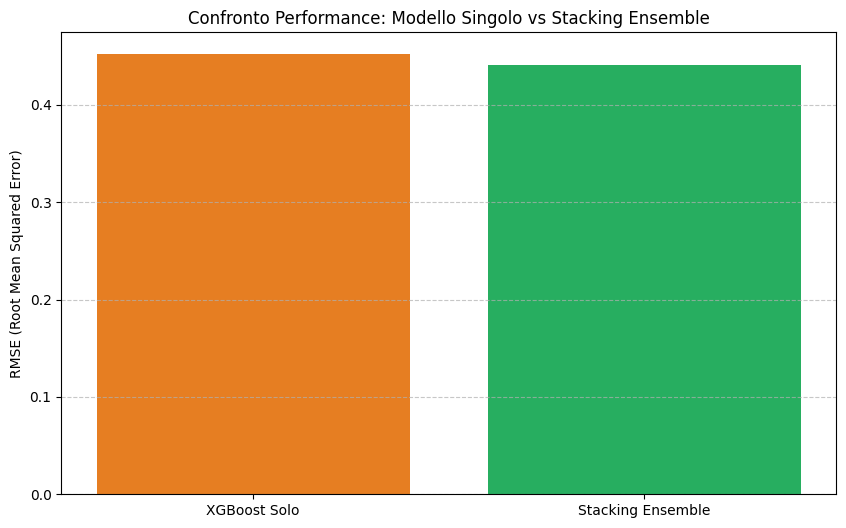

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor

# 1. Caricamento del dataset California Housing
data = fetch_california_housing()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset caricato: {X_train.shape[0]} campioni. Esecuzione su CPU attivata.")

# 2. Definizione dei Modelli Base (Livello 0) - Portati a 1000 estimatori
# Aumentare gli alberi permette una convergenza più precisa
base_models = [
    ('xgb', XGBRegressor(n_estimators=1000, learning_rate=0.03, max_depth=6, 
                         tree_method='hist', device='cpu')), 
    ('lgbm', LGBMRegressor(n_estimators=1000, learning_rate=0.03, num_leaves=31, 
                          device='cpu', verbose=-1)),
    ('cat', CatBoostRegressor(n_estimators=1000, learning_rate=0.03, depth=6, 
                             verbose=0, task_type='CPU'))
]

# --- TEST 1: SINGOLO MODELLO (XGBOOST) ---
print("\n[1/2] Allenamento XGBoost singolo su CPU (1000 estimatori)...")
xgb_solo = XGBRegressor(n_estimators=1000, learning_rate=0.03, tree_method='hist', device='cpu')
xgb_solo.fit(X_train, y_train)
rmse_xgb = root_mean_squared_error(y_test, xgb_solo.predict(X_test))

# --- TEST 2: STACKING ENSEMBLE ---
print("[2/2] Allenamento Stacking Ensemble (XGB + LGBM + Cat)...")
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression(),
    cv=5, 
    n_jobs=-1 # Sfrutta tutti i core del processore
)

stacking_model.fit(X_train, y_train)
rmse_stacking = root_mean_squared_error(y_test, stacking_model.predict(X_test))

# 3. Visualizzazione dei risultati (senza icone)
print("\n" + "-"*40)
print(f"RMSE XGBoost Singolo:   {rmse_xgb:.5f}")
print(f"RMSE Stacking Ensemble:  {rmse_stacking:.5f}")
print(f"Miglioramento percentuale: {((rmse_xgb - rmse_stacking) / rmse_xgb)*100:.2f}%")
print("-"*40)

# 4. Pesi del Meta-Modello (Linear Regression)
coefs = stacking_model.final_estimator_.coef_
print("\nPesi del Meta-Modello (quanto influisce ogni algoritmo):")
for name, coef in zip(['XGB', 'LGBM', 'Cat'], coefs):
    print(f"{name}: {coef:.4f}")

# Grafico di confronto
plt.figure(figsize=(10, 6))
plt.bar(['XGBoost Solo', 'Stacking Ensemble'], [rmse_xgb, rmse_stacking], color=['#e67e22', '#27ae60'])
plt.ylabel('RMSE (Root Mean Squared Error)')
plt.title('Confronto Performance: Modello Singolo vs Stacking Ensemble')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()